# Customer Segmentation with an AI Coding Assistant

This notebook is a guided interface to the reproducible experiment in `src/run_experiment.py`. It compares K-Means, Ward hierarchical clustering, and DBSCAN on standardized age, income, and spending features.

## 1. Setup and dataset audit

Place `Mall_Customers.csv` in `data/` before running. CustomerID and Gender are audited but excluded from the clustering feature matrix.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'Mall_Customers.csv'
OUTPUT_DIR = PROJECT_ROOT / 'artifacts'

df = pd.read_csv(DATA_PATH)
display(df.head())
print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate customer IDs:', int(df['CustomerID'].duplicated().sum()))

Shape: (200, 5)
Missing values: 0
Duplicate rows: 0
Duplicate customer IDs: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Execute the reproducible experiment

The command below regenerates every metric, customer assignment, profile, and figure.

In [2]:
import subprocess
import sys

subprocess.run([
    sys.executable,
    str(PROJECT_ROOT / 'src' / 'run_experiment.py'),
    '--data', str(DATA_PATH),
    '--output', str(OUTPUT_DIR),
], check=True)

CompletedProcess(args=['/opt/codex/runtimes/codex-primary-runtime/dependencies/python/bin/python', '/workspace/scratch/338c5d861c50/CMPE255-Assignments/Assignment-1/Part-2-Coding-Assistant/src/run_experiment.py', '--data', '/workspace/scratch/338c5d861c50/CMPE255-Assignments/Assignment-1/Part-2-Coding-Assistant/data/Mall_Customers.csv', '--output', '/workspace/scratch/338c5d861c50/CMPE255-Assignments/Assignment-1/Part-2-Coding-Assistant/artifacts'], returncode=0)

## 3. Model comparison

DBSCAN's silhouette is computed on non-noise observations, so coverage must be considered beside it.

,model,parameter,n_clusters,coverage,silhouette,davies_bouldin,calinski_harabasz,coverage_adjusted_silhouette
8,K-Means,k=6,6,1.0,0.427428,0.827743,135.102217,0.427428
9,Hierarchical (Ward),k=6,6,1.0,0.420117,0.852102,127.986454,0.420117
14,K-Means,k=9,9,1.0,0.420074,0.854109,131.242316,0.420074
10,K-Means,k=7,7,1.0,0.417232,0.793467,132.774309,0.417232
6,K-Means,k=5,5,1.0,0.416643,0.874551,125.100940,0.416643
12,K-Means,k=8,8,1.0,0.408681,0.889278,131.074446,0.408681
4,K-Means,k=4,4,1.0,0.403958,0.930796,125.676397,0.403958
11,Hierarchical (Ward),k=7,7,1.0,0.398295,0.851329,120.686805,0.398295
16,K-Means,k=10,10,1.0,0.397284,0.905614,133.384828,0.397284
7,Hierarchical (Ward),k=5,5,1.0,0.390028,0.916289,107.826560,0.390028


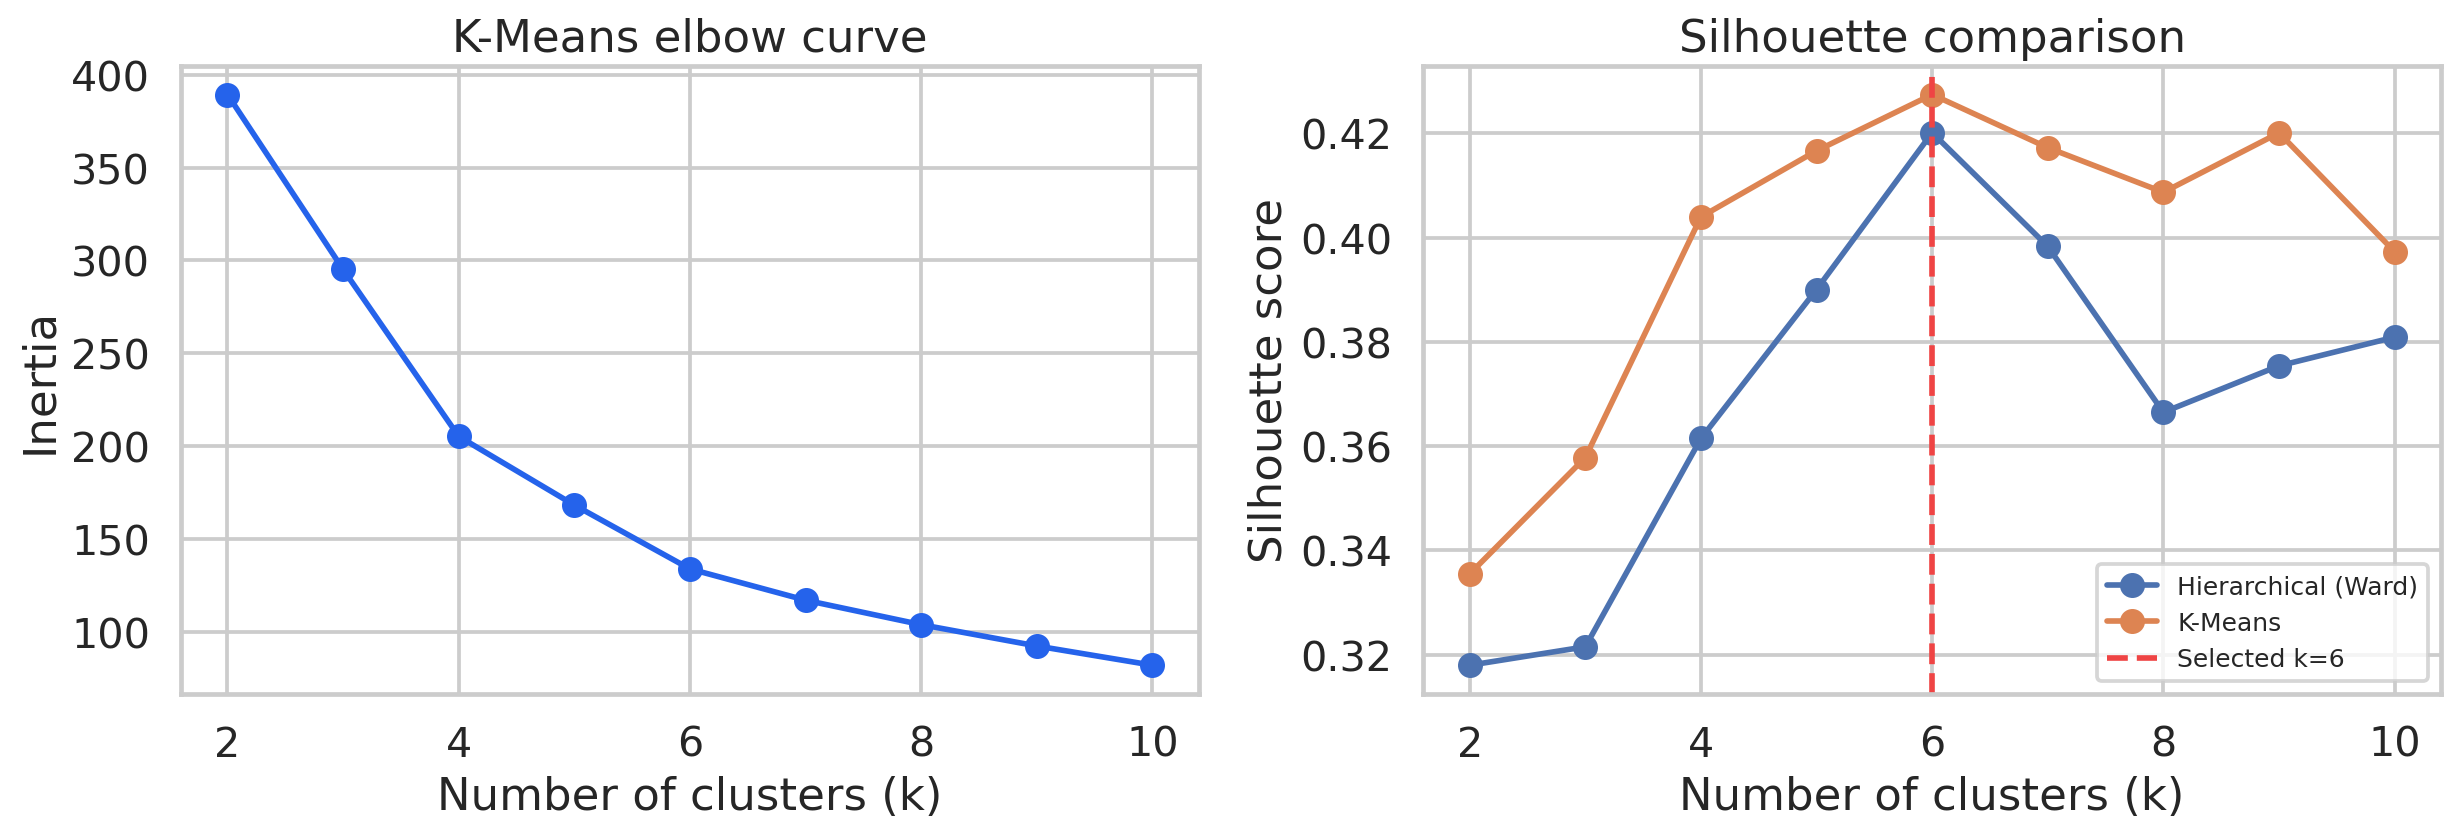

In [3]:
comparison = pd.read_csv(OUTPUT_DIR / 'model-comparison.csv')
display(comparison.sort_values('coverage_adjusted_silhouette', ascending=False).head(12))
display(Image(filename=str(OUTPUT_DIR / 'model-selection.png')))

## 4. Selected customer segments

Six-cluster K-Means is selected because it has the strongest full-coverage silhouette score and assigns every customer. Persona names summarize cluster averages and are not causal or psychological labels.

,Cluster,Customers,Mean_Age,Mean_Income_k,Mean_Spending_Score,Female_Share,Persona
0,0,33,41.939394,88.939394,16.969697,0.424242,Midlife affluent cautious
1,1,45,56.333333,54.266667,49.066667,0.577778,Mature mid-income mainstream
2,2,24,25.250000,25.833333,76.916667,0.583333,Young budget enthusiasts
3,3,39,32.692308,86.538462,82.128205,0.538462,Young affluent enthusiasts
4,4,38,26.684211,57.578947,47.789474,0.631579,Young mid-income mainstream
5,5,21,45.523810,26.285714,19.380952,0.619048,Mature budget cautious


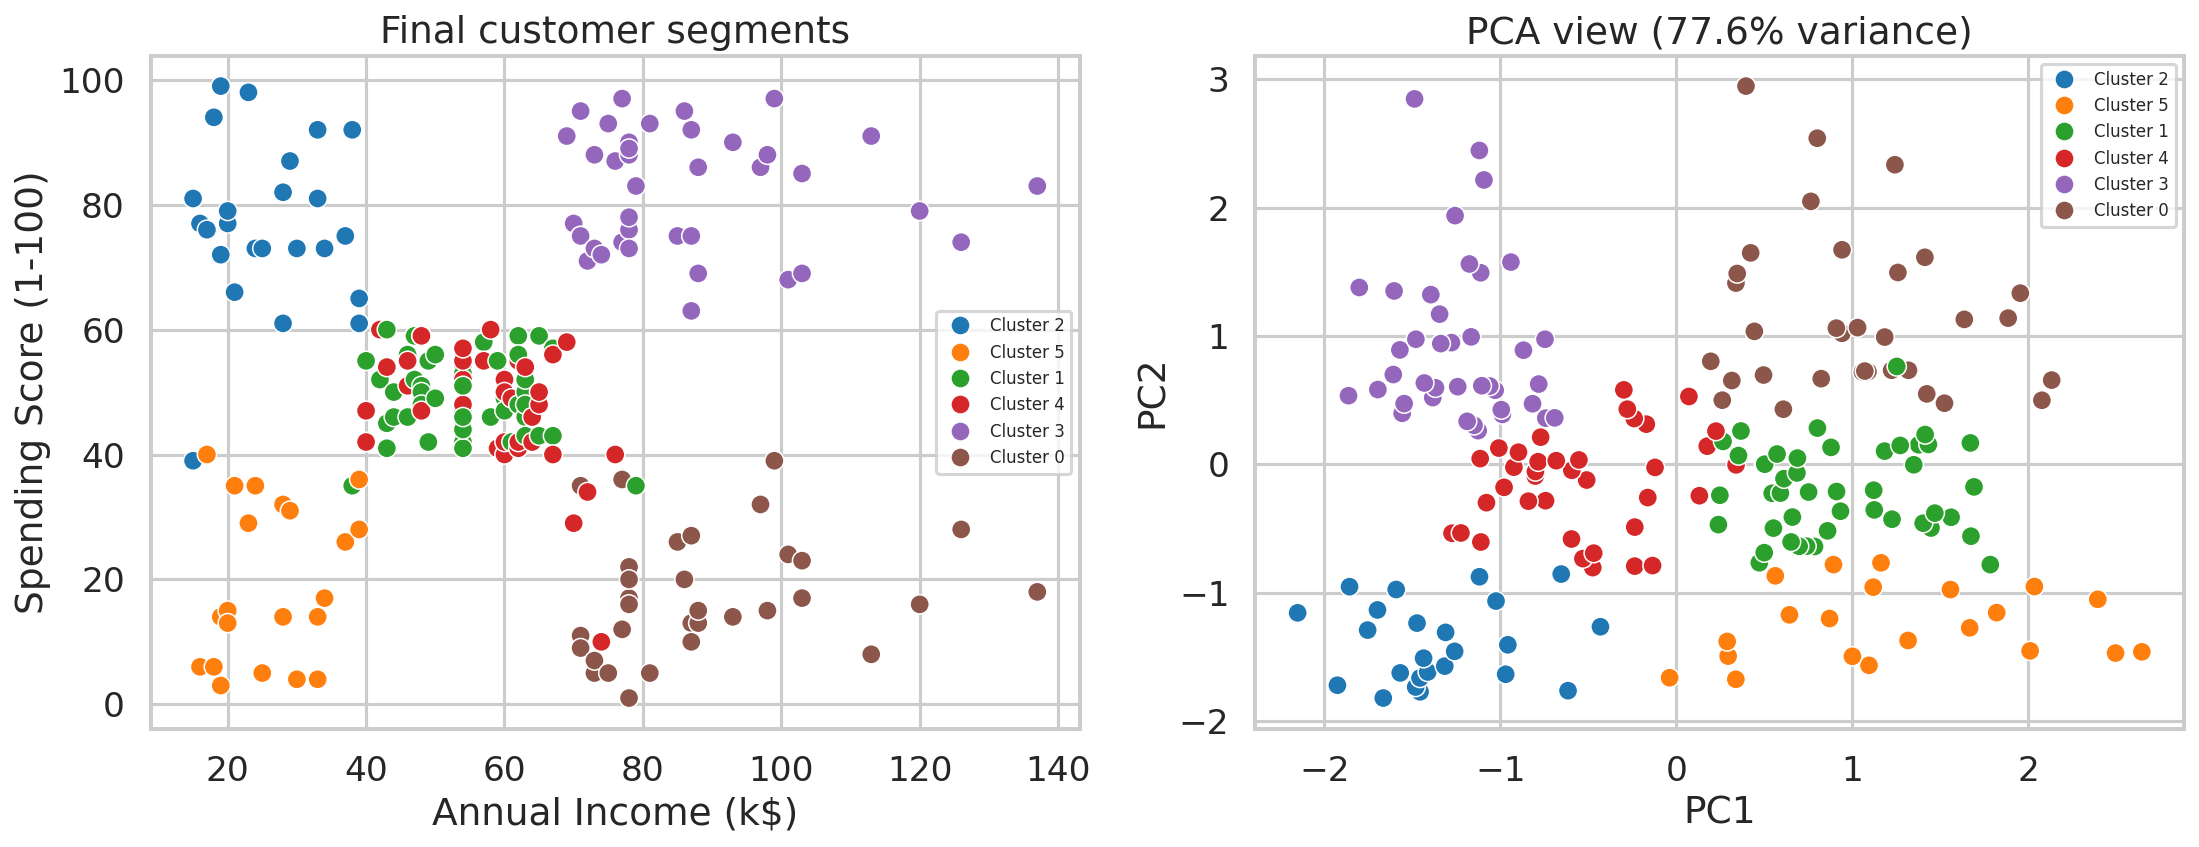

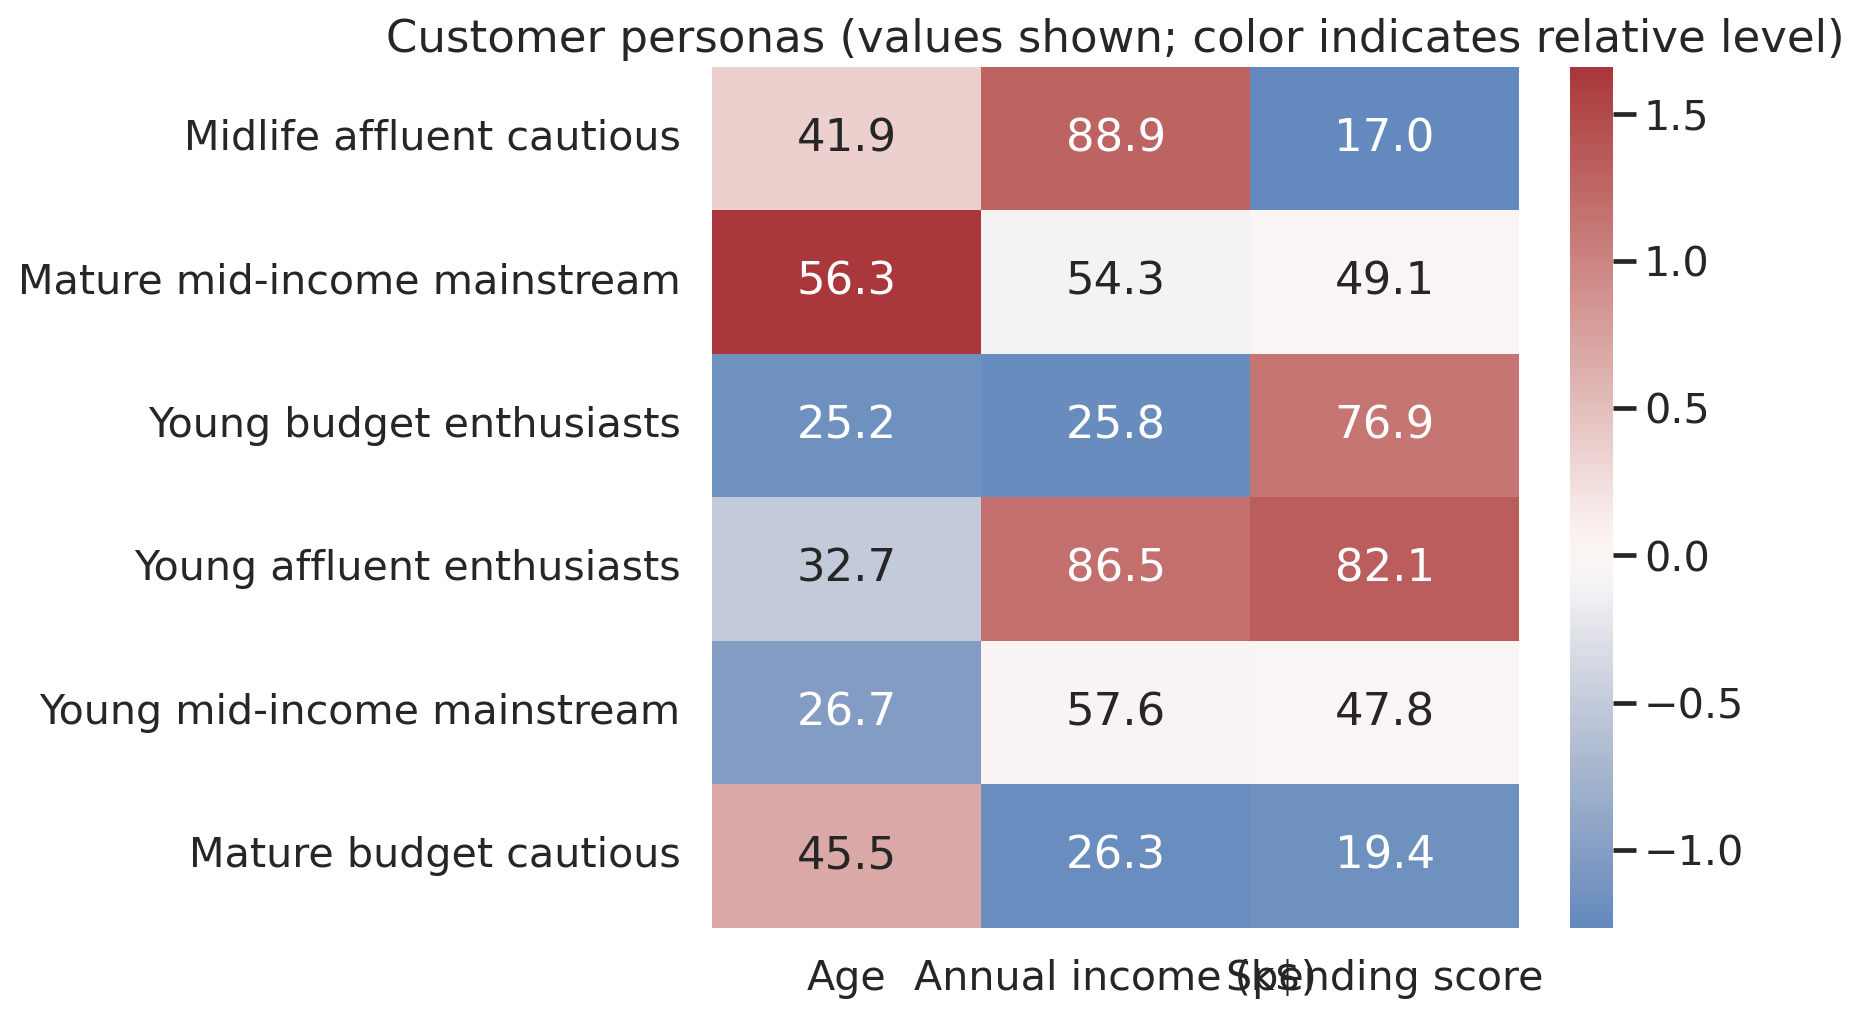

In [4]:
profiles = pd.read_csv(OUTPUT_DIR / 'cluster-profiles.csv')
display(profiles)
display(Image(filename=str(OUTPUT_DIR / 'customer-segments.png')))
display(Image(filename=str(OUTPUT_DIR / 'cluster-personas.png')))

## 5. Verified summary and limitations

Internal metrics quantify geometric separation, not business value. External validation, stability tests, campaign outcomes, and drift monitoring would be required before deployment.

In [5]:
summary = json.loads((OUTPUT_DIR / 'results-summary.json').read_text())
summary

{'data_audit': {'rows': 200, 'columns': 5, 'missing_values': 0, 'duplicate_rows': 0, 'duplicate_customer_ids': 0}, 'features': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], 'scaling': 'StandardScaler', 'selected_model': 'K-Means', 'selected_k': 6, 'kmeans_silhouette': 0.4274, 'hierarchical_best_parameter': 'k=6', 'hierarchical_best_silhouette': 0.4201, 'dbscan_parameter': 'eps=0.55, min_samples=8', 'dbscan_silhouette_non_noise': 0.5158, 'dbscan_coverage': 0.69, 'pca_explained_variance_2d': 0.7757, 'selection_note': 'K-Means was selected for full customer assignment and interpretability; DBSCAN metrics exclude noise and are reported with coverage.'}